In [1]:
import sys 
sys.path.append('LIBS')
from LIBS.utils import *


/home/clod/anaconda3/envs/openmm-dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = get_dataset(scale_pos=False, return_pos_angstrom=False)

Loading dataset ...
Root directory: None
TPR file: MD.tpr
Trajectory file: MD_with_solvent_noPBC.xtc
Selection: protein
Include atom type: True
Scale features: True
Scale positions: False
Initial alignment: False
Return max position: False
Return position in Angstrom: False
No root directory provided, using default path ...
Successfully loaded processed data from /home/clod/Desktop/THESIS_2/FULL_ATOM/DATA/processed/data_MD_protein.pt
Converting positions to nm ...
Positions shape: torch.Size([20032, 52, 3])
Including atom features: performing one hot encoding ...
Scaling features ...
not aligning the frames ...
Dataset created with 20032 graphs.
Number of graphs in the dataset: 20032
Number of features in the dataset: 6
Number of edges in the dataset: 102
Number of nodes in the dataset: 52
Number of features in the dataset: torch.Size([52, 6])



In [3]:
# Get the distances between all the nodes

positions = dataset[0].pos
#distances = torch.cdist(positions, positions)
distances = torch.cdist(positions, positions, p=2)
# remove the diagonal (self-distances)
distances = distances[distances != 0]

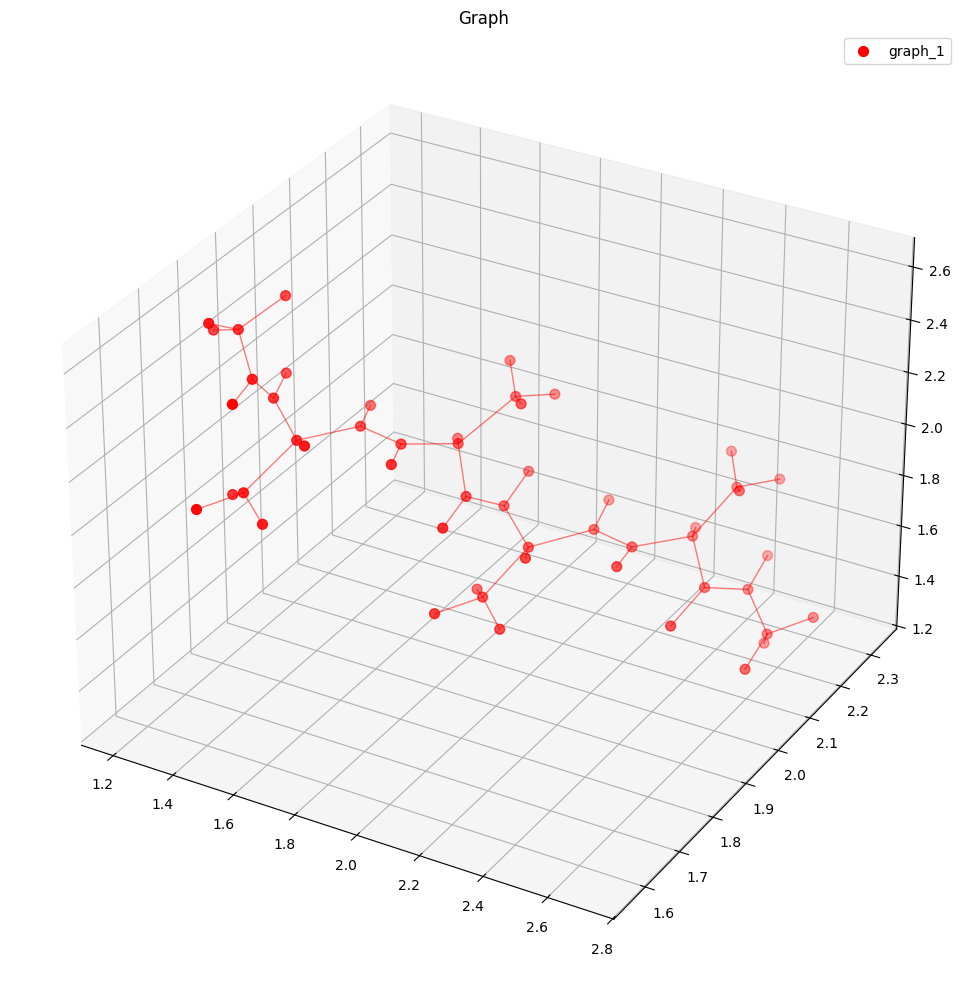

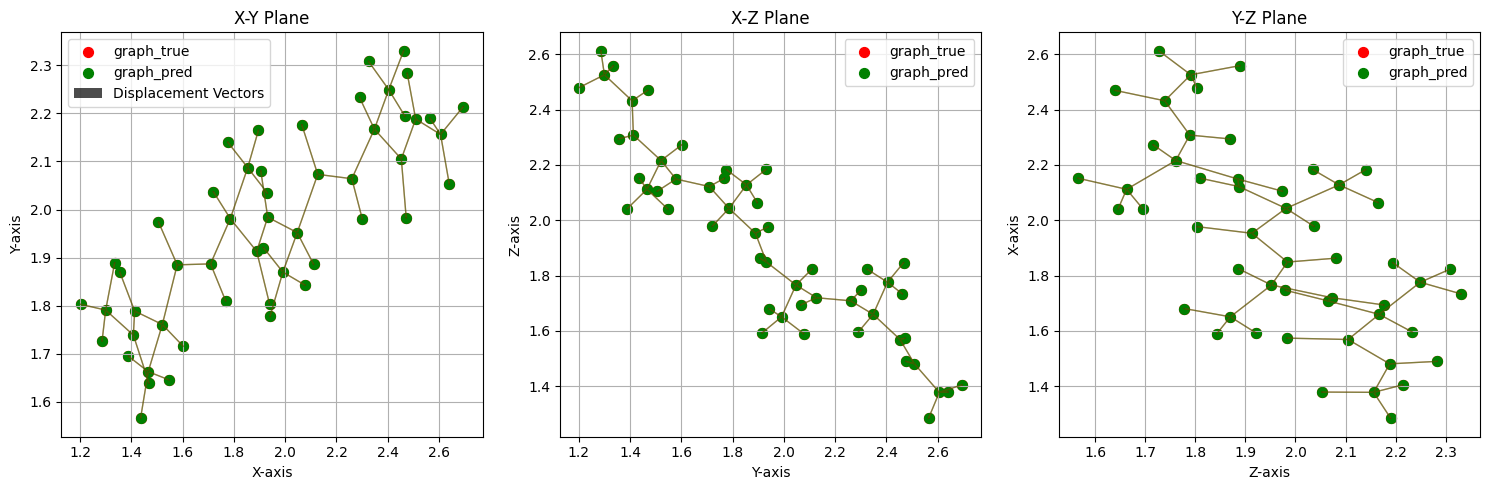

In [4]:
plot_graph_dataset(dataset,1)
plot_graph_pred(dataset[0].pos, dataset[0], planewise= True)

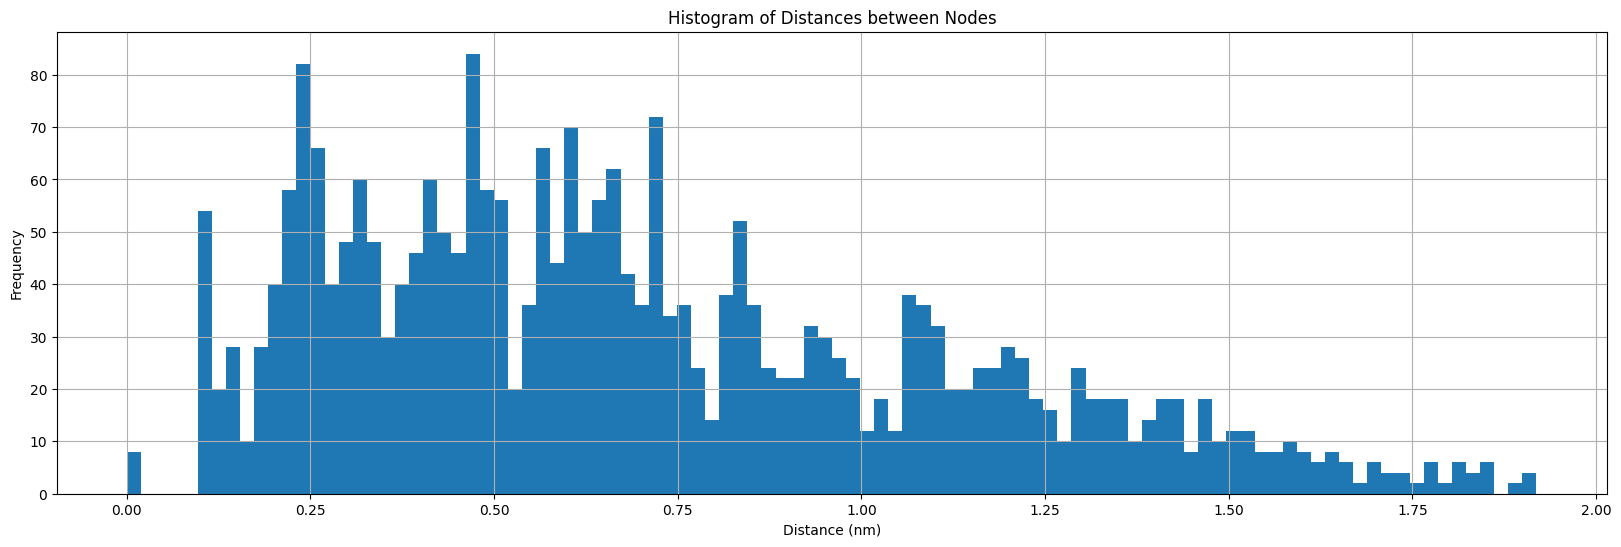

In [5]:
# plot an histogram of the distances
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 6))
plt.title('Histogram of Distances between Nodes')

plt.hist(distances.flatten().numpy(), bins=100)
plt.xlabel('Distance (nm)')
plt.ylabel('Frequency')
plt.title('Histogram of Distances between Nodes')
plt.grid(True)
plt.show()

In [6]:
# find where the distance are smaller than 0.5 nm
small_distances = distances[distances < 0.1]
print(f'Number of distances smaller than 0.1 nm: {small_distances.shape[0]}')
print(f'Mean of small distances: {small_distances.mean().item()}')
print(f'Standard deviation of small distances: {small_distances.std().item()}')

Number of distances smaller than 0.1 nm: 8
Mean of small distances: 0.001279941527172923
Standard deviation of small distances: 0.00018724962137639523


In [7]:
# get smaller distances
smaller_distances = torch.sort(small_distances)[0]
print(f'Smaller distances: {smaller_distances}')

Smaller distances: tensor([0.0010, 0.0010, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014])


In [8]:
#compute lj potential for first data point 
from LIBS.force_field import *
physics_critic = EnergyCalculator(pdb_file= '../DATA/raw/protein_only.pdb')

list_cutoff = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
for cutoff in list_cutoff:
    lj_potential = physics_critic.lennard_jones_energy(dataset[0].pos, cutoff=cutoff)
    print(f'Lennard-Jones potential for first data point with cutoff {cutoff}: {lj_potential.item()}')

print()
print(f'Energy computed using OpenMM: {physics_critic.openMM_energy(dataset[0].pos).item()}')

Using OpenMM platform: CUDA
Lennard-Jones potential for first data point with cutoff 0: 4126.83349609375
Lennard-Jones potential for first data point with cutoff 0.1: 0.0
Lennard-Jones potential for first data point with cutoff 0.2: 587.9818115234375
Lennard-Jones potential for first data point with cutoff 0.3: 4160.7353515625
Lennard-Jones potential for first data point with cutoff 0.4: 4145.9658203125
Lennard-Jones potential for first data point with cutoff 0.5: 4132.05322265625

Energy computed using OpenMM: 117.98239135742188


In [9]:
from LIBS.upgraded_ff import EnergyCalculator as EC

energy_calc = EC(pdb_file='../DATA/raw/protein_only.pdb')

# Get initial coordinates in the correct unit (nm)
initial_pos_nm = energy_calc.positions.value_in_unit(unit.nanometer)
coords_tensor = torch.tensor(initial_pos_nm, dtype=torch.float32)

# --- VERIFICATION ---

# 1. Calculate non-bonded energy with our PyTorch implementation
pytorch_nonbonded_energy = energy_calc.nonbonded_energy(coords_tensor)

# 2. Calculate non-bonded energy with OpenMM using force groups
openmm_nonbonded_energy = energy_calc.openMM_nonbonded_energy(coords_tensor)

print(f"PyTorch Non-Bonded Energy: {pytorch_nonbonded_energy.item():.4f} kJ/mol")
print(f"OpenMM Non-Bonded Energy:  {openmm_nonbonded_energy:.4f} kJ/mol")

# The two values above should now be very close!
# (Small differences can arise from float32 vs float64 precision)

Using OpenMM platform for reference calculations: CPU
PyTorch Non-Bonded Energy: -122.9197 kJ/mol
OpenMM Non-Bonded Energy:  -122.9222 kJ/mol


In [10]:
from LIBS.upgraded_ff import EnergyCalculator as EC

physics_critic_upd = EC(pdb_file= '../DATA/raw/protein_only.pdb')
initial_pos_nm = physics_critic_upd.positions.value_in_unit(unit.nanometer)
coords_tensor = torch.tensor(initial_pos_nm, dtype=torch.float32)

# --- VERIFICATION ---
pytorch_nonbonded_energy = physics_critic_upd.nonbonded_energy(coords_tensor)
openmm_nonbonded_energy = physics_critic_upd.openMM_nonbonded_energy(coords_tensor)

print(f"PyTorch Non-Bonded Energy: {pytorch_nonbonded_energy.item():.4f} kJ/mol")
print(f"OpenMM Non-Bonded Energy:  {openmm_nonbonded_energy:.4f} kJ/mol")

# Calculate difference
diff = abs(pytorch_nonbonded_energy.item() - openmm_nonbonded_energy)
print(f"Difference: {diff:.4f} kJ/mol")



Using OpenMM platform for reference calculations: CPU
PyTorch Non-Bonded Energy: -122.9197 kJ/mol
OpenMM Non-Bonded Energy:  -122.9222 kJ/mol
Difference: 0.0025 kJ/mol


In [11]:
import openmm as mm

# compute lj potential for first data point with OpenMM
from openmm import app
from openmm import unit
pdb = app.PDBFile('../DATA/raw/protein_only.pdb')
forcefield = app.ForceField('amber14-all.xml', 'amber14/tip3p.xml')
system = forcefield.createSystem(pdb.topology, nonbondedMethod=app.NoCutoff, constraints=app.HBonds)
integrator = mm.VerletIntegrator(0.001 * unit.picoseconds)
simulation = app.Simulation(pdb.topology, system, integrator)
simulation.context.setPositions(pdb.positions)
simulation.context.setVelocitiesToTemperature(300 * unit.kelvin)
lj_potential_openmm = simulation.context.getState(getEnergy=True).getPotentialEnergy()
print(f'Lennard-Jones potential for first data point with OpenMM: {lj_potential_openmm.value_in_unit(unit.kilojoule_per_mole)} kJ/mol') 

Lennard-Jones potential for first data point with OpenMM: 126.34408569335938 kJ/mol


In [30]:
from LIBS.upgraded_ff import *
trainset, _, _ = get_dataloaders(dataset,batch_size=2)

for data in trainset:
    # print(f'Batch size: {data.pos.shape[0]}')
    # print(f'Number of nodes in batch: {data.pos.shape[1]}')
    # print(f'Number of edges in batch: {data.edge_index.shape[1]}')

    ph_loss = physics_loss(physics_critic_upd, data.pos, data.batch, use_log=False)
    print(f'Physics loss for batch: {ph_loss.item()}')

Physics loss for batch: 53.69436264038086
Physics loss for batch: 21.990943908691406
Physics loss for batch: 26.26087188720703
Physics loss for batch: 15.376327514648438
Physics loss for batch: 55.24909210205078
Physics loss for batch: 14.272930145263672
Physics loss for batch: 53.62583541870117
Physics loss for batch: 30.95937728881836
Physics loss for batch: 31.45966339111328
Physics loss for batch: 52.50043487548828
Physics loss for batch: -0.07938003540039062
Physics loss for batch: 58.59715270996094
Physics loss for batch: 19.330154418945312
Physics loss for batch: 62.95726013183594
Physics loss for batch: 32.6919059753418
Physics loss for batch: 26.506916046142578
Physics loss for batch: 6.942722320556641
Physics loss for batch: 40.379817962646484
Physics loss for batch: 15.06839370727539
Physics loss for batch: 34.38111114501953
Physics loss for batch: 43.384159088134766
Physics loss for batch: 22.803470611572266
Physics loss for batch: 15.370655059814453
Physics loss for batch:

KeyboardInterrupt: 